# EDA — All-Schools VPD Coverage

School-level measles (MMR) vaccination coverage for CA and NC: overall + per-grade
estimates, risk tiers, geocoordinates. Includes light wrangling that previews the
reshape into imuGAP inputs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (8, 4)

DATA = Path("../data/all-schools.csv")
if not DATA.exists():
    DATA = Path("data/all-schools.csv")

df = pd.read_csv(DATA)
df.shape

(9831, 31)

In [2]:
df.head()

,state,school_id,school_name,county,enrollment,lon,lat,no_data,coverage,coverage_ci_low,...,coverage_ci_low_4,coverage_ci_low_5,coverage_ci_high_K,coverage_ci_high_1,coverage_ci_high_2,coverage_ci_high_3,coverage_ci_high_4,coverage_ci_high_5,prob_below_95,tier
0,ca,26,the academy of alameda elementary,Alameda,46.0,-122.2854,37.7773,0,0.9683,0.9436,...,0.9555,0.9515,0.9697,0.9900,0.9921,0.9928,0.9927,0.9920,0.0605,H
1,ca,28,Achieve Academy,Alameda,108.0,-122.1984,37.7357,0,0.9794,0.9587,...,0.9682,0.9653,0.9615,0.9840,0.9871,0.9882,0.9881,0.9870,0.0008,H
2,ca,29,Acorn Woodland Elementary School,Alameda,51.0,-122.1870,37.7535,0,0.9778,0.9656,...,0.9740,0.9716,0.9760,0.9945,0.9958,0.9961,0.9961,0.9957,0.0000,H
3,ca,32,Acts Christian Academy,Alameda,21.0,-122.1960,37.7586,0,0.9225,0.8538,...,0.8786,0.8688,0.9050,0.9416,0.9520,0.9559,0.9555,0.9515,0.9912,M
4,ca,66,Alameda County Community,Alameda,104.0,-122.0983,37.6585,0,0.9960,0.9803,...,0.9862,0.9849,0.9826,0.9994,0.9998,0.9998,0.9998,0.9998,0.0000,H


In [3]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
school_id,9831.0,16660.482,12496.392,26.000,3508.000,16056.000,27405.500,38660.000
enrollment,9295.0,71.540,46.477,1.000,36.000,68.000,97.000,953.000
lon,7473.0,-119.470,2.547,-124.268,-121.604,-118.738,-117.897,-75.789
lat,7473.0,35.668,2.135,32.548,33.937,34.436,37.698,41.964
no_data,9831.0,0.013,0.115,0.000,0.000,0.000,0.000,1.000
coverage,9699.0,0.958,0.069,0.184,0.956,0.980,0.990,1.000
coverage_ci_low,7877.0,0.939,0.097,0.048,0.938,0.970,0.984,0.996
coverage_ci_high,7877.0,0.975,0.064,0.124,0.980,0.994,0.997,0.997
coverage_K,9699.0,0.943,0.098,0.046,0.949,0.970,0.983,1.000
coverage_1,9699.0,0.955,0.091,0.000,0.956,0.984,0.995,1.000


## Missing values

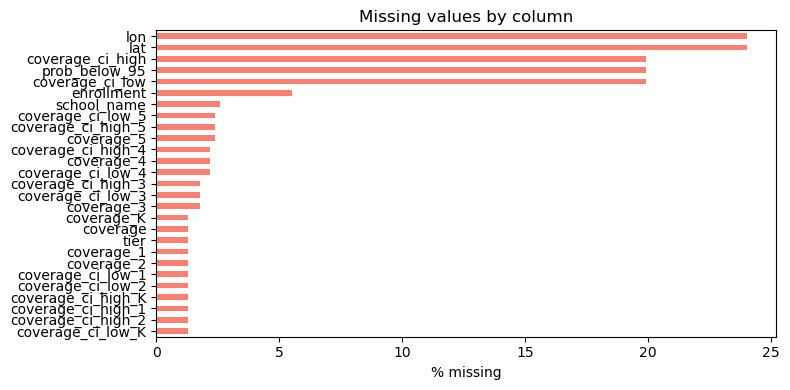

In [4]:
miss = df.isna().mean().mul(100).round(1)
miss = miss[miss > 0].sort_values()
miss.plot.barh(color="salmon")
plt.xlabel("% missing"); plt.title("Missing values by column")
plt.tight_layout(); plt.show()

## Counts & geography

In [5]:
print("rows:", len(df))
print("unique school_id:", df.school_id.nunique(), "(not globally unique)")
print("unique (state, school_id):", df.groupby(["state", "school_id"]).ngroups)
print("counties:", df.county.nunique())
df.state.value_counts()

rows: 9831
unique school_id: 9497 (not globally unique)
unique (state, school_id): 9831
counties: 157


state
ca    8009
nc    1822
Name: count, dtype: int64

## Coverage distribution

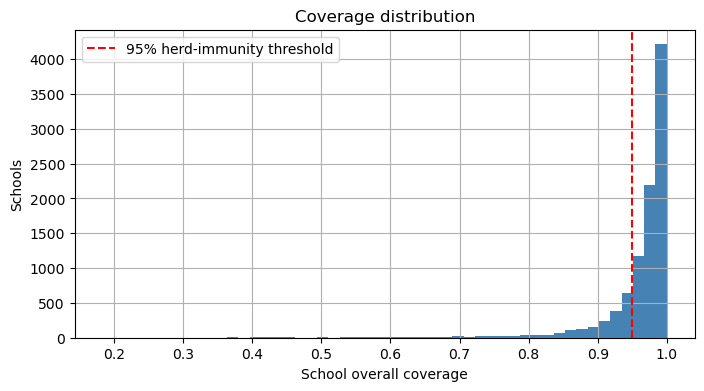

In [6]:
fig, ax = plt.subplots()
df["coverage"].hist(bins=50, ax=ax, color="steelblue")
ax.axvline(0.95, color="red", ls="--", label="95% herd-immunity threshold")
ax.set(xlabel="School overall coverage", ylabel="Schools", title="Coverage distribution")
ax.legend(); plt.show()

## Risk tiers & threshold probability

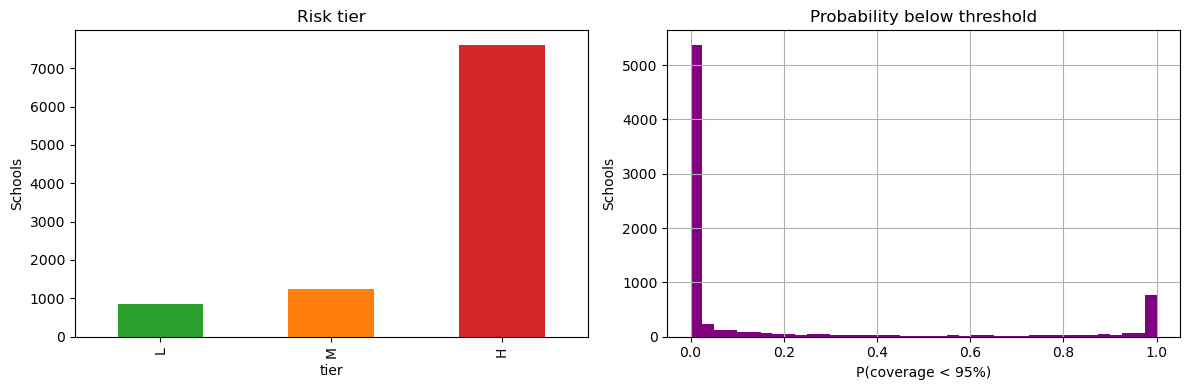

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["tier"].value_counts().reindex(["L", "M", "H"]).plot.bar(
    ax=axes[0], color=["#2ca02c", "#ff7f0e", "#d62728"])
axes[0].set(ylabel="Schools", title="Risk tier", xlabel="tier")
df["prob_below_95"].hist(bins=40, ax=axes[1], color="purple")
axes[1].set(xlabel="P(coverage < 95%)", ylabel="Schools", title="Probability below threshold")
plt.tight_layout(); plt.show()

## Wrangling: namespaced keys + wide grades → long

In [8]:
df["state_school"] = df["state"] + "::" + df["school_id"].astype(str)
df["state_county"] = df["state"] + "::" + df["county"].astype(str)

grades = ["coverage_K", "coverage_1", "coverage_2", "coverage_3", "coverage_4", "coverage_5"]
age_map = {"coverage_K": 5, "coverage_1": 6, "coverage_2": 7,
           "coverage_3": 8, "coverage_4": 9, "coverage_5": 10}

long = (df.melt(id_vars=["state", "state_county", "state_school", "enrollment"],
                value_vars=grades, var_name="grade", value_name="grade_coverage")
          .dropna(subset=["grade_coverage"]))
long["age"] = long["grade"].map(age_map)
long.head()

,state,state_county,state_school,enrollment,grade,grade_coverage,age
0,ca,ca::Alameda,ca::26,46.0,coverage_K,0.9348,5
1,ca,ca::Alameda,ca::28,108.0,coverage_K,0.9907,5
2,ca,ca::Alameda,ca::29,51.0,coverage_K,0.9412,5
3,ca,ca::Alameda,ca::32,21.0,coverage_K,0.9524,5
4,ca,ca::Alameda,ca::66,104.0,coverage_K,0.9904,5


## Coverage by grade

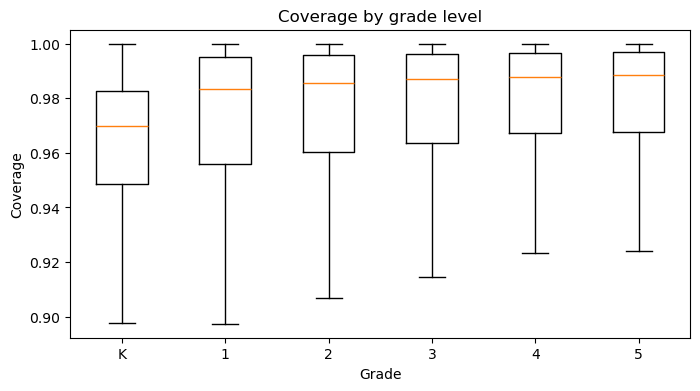

In [9]:
data = [df[g].dropna() for g in grades]
plt.boxplot(data, tick_labels=["K", "1", "2", "3", "4", "5"], showfliers=False)
plt.xlabel("Grade"); plt.ylabel("Coverage"); plt.title("Coverage by grade level")
plt.show()

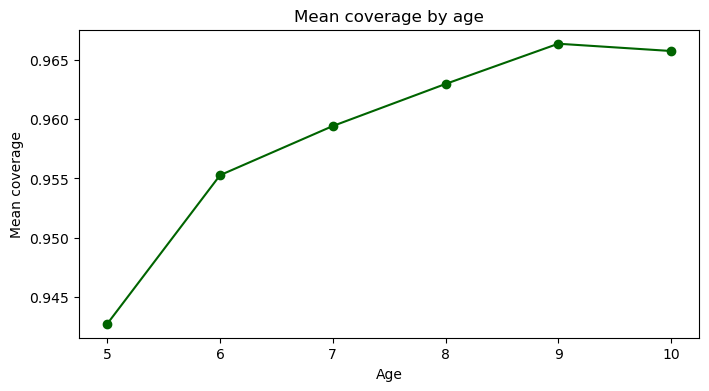

In [10]:
m = long.groupby("age")["grade_coverage"].mean()
m.plot(marker="o", color="darkgreen")
plt.ylabel("Mean coverage"); plt.xlabel("Age"); plt.title("Mean coverage by age")
plt.show()

## Enrollment & its effect on coverage

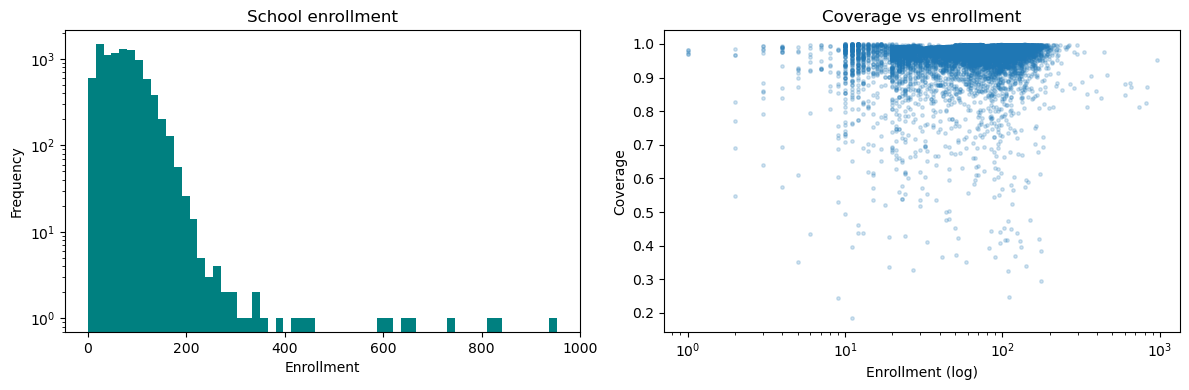

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["enrollment"].dropna().plot.hist(bins=60, ax=axes[0], color="teal")
axes[0].set(xlabel="Enrollment", title="School enrollment", yscale="log")
axes[1].scatter(df["enrollment"], df["coverage"], s=6, alpha=0.2)
axes[1].set(xscale="log", xlabel="Enrollment (log)", ylabel="Coverage",
            title="Coverage vs enrollment")
plt.tight_layout(); plt.show()

## No-data schools (imputation targets)

In [12]:
print("no_data schools:", int((df["no_data"] == 1).sum()))
df.groupby("state")["no_data"].sum()

no_data schools: 132


state
ca    132
nc      0
Name: no_data, dtype: int64

## Spatial view

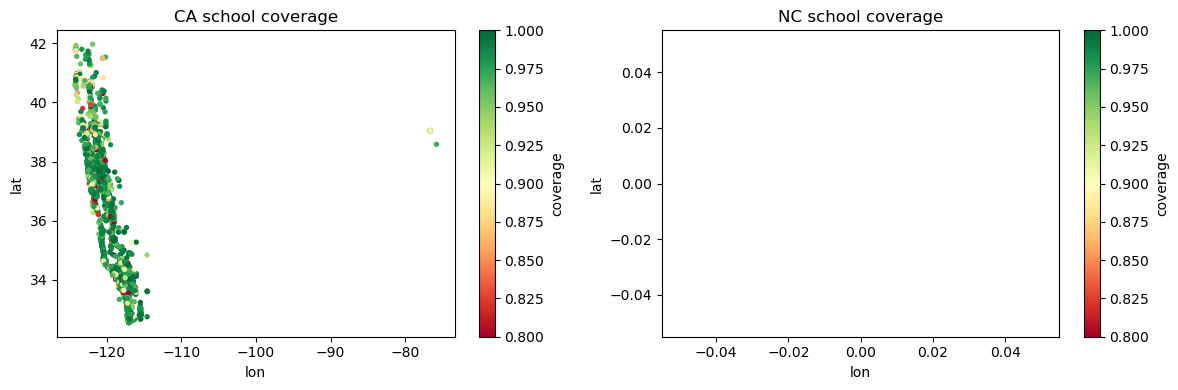

In [13]:
geo = df.dropna(subset=["lon", "lat"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, st in zip(axes, ["ca", "nc"]):
    sub = geo[geo["state"] == st]
    sc = ax.scatter(sub["lon"], sub["lat"], c=sub["coverage"],
                    cmap="RdYlGn", s=8, vmin=0.8, vmax=1.0)
    ax.set(title=f"{st.upper()} school coverage", xlabel="lon", ylabel="lat")
    fig.colorbar(sc, ax=ax, label="coverage")
plt.tight_layout(); plt.show()

## County summary

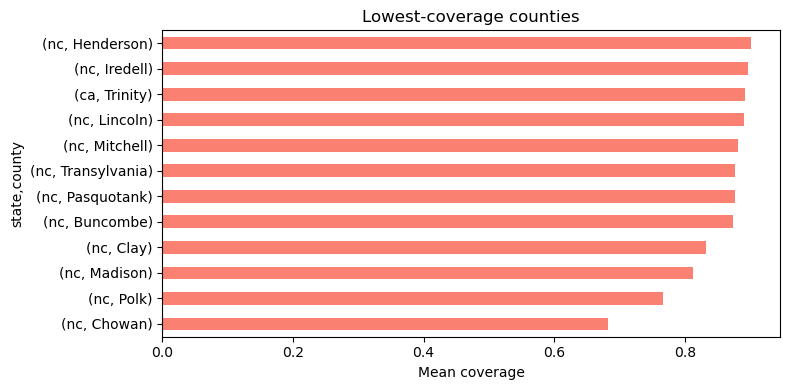

In [14]:
cty = df.groupby(["state", "county"])["coverage"].mean().sort_values()
cty.head(12).plot.barh(color="salmon")
plt.xlabel("Mean coverage"); plt.title("Lowest-coverage counties")
plt.tight_layout(); plt.show()

## Takeaways

- Coverage is high overall but left-skewed; a real tail sits below the 95% threshold.
- `school_id` is not globally unique (CA/NC reuse ids) → namespace by state.
- 132 `no_data` schools + per-grade gaps are the imputation targets for imuGAP.
- Small schools show far wider coverage spread → motivates partial pooling.
- 24% of schools lack lon/lat → spatial maps are partial until geocoded.